In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/cleaned/ipo_cleaned.csv')

print("Shape:", df.shape)
print("Year range:", df['Year'].min(), "to", df['Year'].max())

# GroupBy Year — calculate multiple metrics per year
yearly = df.groupby('Year').agg(
    total_ipos        = ('IPO_Name', 'count'),
    avg_listing_gain  = ('Listing Gain', 'mean'),
    median_listing_gain = ('Listing Gain', 'median'),
    avg_qib           = ('QIB', 'mean'),
    avg_rii           = ('RII', 'mean'),
    pct_profitable    = ('Listing Gain', lambda x: (x > 0).sum() / len(x) * 100)
).round(2).reset_index()

print("\nYear-wise Summary")
print(yearly.to_string())

Shape: (549, 19)
Year range: 2010 to 2025

Year-wise Summary
    Year  total_ipos  avg_listing_gain  median_listing_gain  avg_qib  avg_rii  pct_profitable
0   2010          69             10.08                 5.56    20.03     6.80           73.91
1   2011          35              2.90                 0.91     2.54     4.71           51.43
2   2012          10              5.86                 1.72    12.68     4.22           70.00
3   2013           4              4.50                 5.38    32.73     2.90           75.00
4   2014           6             25.13                18.84    18.14    12.07           66.67
5   2015          19              7.13                 0.00    18.10     1.99           47.37
6   2016          27             12.35                 9.59    25.48     4.91           74.07
7   2017          38             21.48                 5.14    43.73     9.05           65.79
8   2018          24              5.26                 1.35    31.67     4.75           50.00

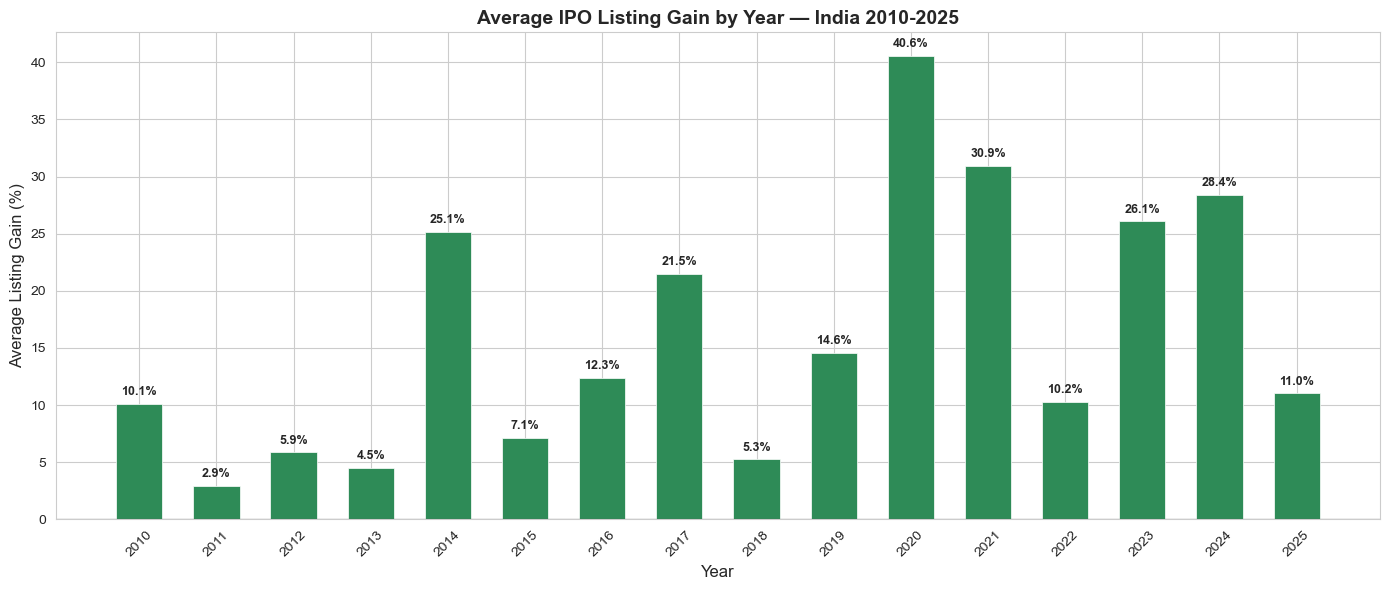

Chart saved.


In [3]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
fig, ax = plt.subplots()
# Color bars — green for positive years, red for negative
colors = ['seagreen' if x >= 0 else 'crimson'
          for x in yearly['avg_listing_gain']]
bars = ax.bar(
    yearly['Year'],
    yearly['avg_listing_gain'],
    color=colors,
    edgecolor='white',
    linewidth=0.5,
    width=0.6
)
# Add value labels on top of each bar
for bar, val in zip(bars, yearly['avg_listing_gain']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')

ax.set_title('Average IPO Listing Gain by Year — India 2010-2025',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Average Listing Gain (%)', fontsize=12)
ax.set_xticks(yearly['Year'])
ax.set_xticklabels(yearly['Year'], rotation=45)

plt.tight_layout()
plt.savefig('../charts/05_yearwise_listing_gain.png', dpi=150)
plt.show()
print("Chart saved.")